# Getting US Macro Indicators

Pull three series from FRED and build the standard macro state $(y, \pi, i)$:

| Symbol | FRED ID | Description | Native freq. | Transformation |
|--------|---------|-------------|--------------|----------------|
| $y$ | `A939RX0Q048SBEA` | Real GDP per capita (chained \$) | Quarterly | $y=\log(\text{output per capita})$ |
| $\pi$ | `CPILFESL` | Core CPI (all items less food & energy) | Monthly | inflation rate, % per year |
| $i$ | `TB3MS` | 3-Month T-Bill secondary market rate, discount basis | Monthly | already % per year |

**Frequency note.** Real GDP per capita is only published quarterly, so quarterly is the common frequency. The two monthly series are aggregated to quarters by averaging within the quarter.

**Inflation.** Core CPI is an index, so it is converted to an *annualized quarter-over-quarter* rate:
$\pi_t = 400 \cdot \big[\log(\text{CPI}_t) - \log(\text{CPI}_{t-1})\big]$ (percent per year). A year-over-year alternative is included below, commented out.

Data are downloaded from FRED's public CSV endpoint (`fredgraph.csv`), which requires no API key.

In [4]:
import numpy as np
import pandas as pd


def fred_series(series_id: str) -> pd.Series:
    """Download a single series from FRED's public CSV endpoint (no API key needed)."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    s = pd.read_csv(
        url, parse_dates=["observation_date"], index_col="observation_date"
    )[series_id]
    return pd.to_numeric(s, errors="coerce").rename(series_id)  # "." -> NaN

In [5]:
# --- Download raw series from FRED ---------------------------------------
real_gdp_pc = fred_series("A939RX0Q048SBEA")  # real GDP per capita, chained $, quarterly
core_cpi    = fred_series("CPILFESL")          # core CPI index, monthly
tbill_3m    = fred_series("TB3MS")             # 3-month T-bill rate, % per year, monthly

raw = pd.concat([real_gdp_pc, core_cpi, tbill_3m], axis=1)
print(raw.describe())
raw.tail()

       A939RX0Q048SBEA    CPILFESL        TB3MS
count       317.000000  832.000000  1110.000000
mean      38424.315457  143.006530     3.418847
std       16179.874134   89.409914     3.087336
min       15032.000000   28.500000     0.010000
25%       24446.000000   48.350000     0.387500
50%       36822.000000  143.150000     2.965000
75%       53719.000000  217.046750     5.207500
max       70583.000000  336.121000    16.300000


C:\Users\xiang\AppData\Local\Temp\ipykernel_2188\3408638179.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  raw = pd.concat([real_gdp_pc, core_cpi, tbill_3m], axis=1)


,A939RX0Q048SBEA,CPILFESL,TB3MS
observation_date,,,
2026-02-01,NaN,333.512,3.60
2026-03-01,NaN,334.165,3.61
2026-04-01,NaN,335.423,3.61
2026-05-01,NaN,336.121,3.60
2026-06-01,NaN,NaN,3.66


In [6]:
# --- Transform to (y, pi, i) at quarterly frequency -----------------------

# y: log of real output per capita (already quarterly)
y = np.log(real_gdp_pc).rename("y")

# Aggregate the monthly series to quarters by averaging within the quarter.
cpi_q = core_cpi.resample("QS").mean()             # quarterly avg core CPI index
i     = tbill_3m.resample("QS").mean().rename("i")  # quarterly avg nominal rate, % / yr

# pi: inflation rate in percent per year.
# Annualized quarter-over-quarter log change of core CPI.
pi = (400.0 * np.log(cpi_q).diff()).rename("pi")
# Year-over-year alternative:
# pi = (100.0 * (cpi_q / cpi_q.shift(4) - 1.0)).rename("pi")

macro = pd.concat([pi, i], axis=1, sort=False).dropna()
macro.tail()

,pi,i
observation_date,,
2025-04-01,2.136134,4.230000
2025-07-01,3.160511,4.096667
2025-10-01,2.212921,3.730000
2026-01-01,2.480312,3.593333
2026-04-01,2.727791,3.623333


In [7]:
macro_sample=macro.loc["2015-01-01":"2026-04-01"]


In [8]:
# Attach y with a left join on macro_sample's index so the 2026-04-01 (Q2) row is kept.
macro_sample = macro_sample.join(y)          # y is quarterly; aligns on quarter-start dates
macro_sample = macro_sample[["y", "pi", "i"]]  # column order
macro_sample.tail()

,y,pi,i
observation_date,,,
2025-04-01,11.149787,2.136134,4.230000
2025-07-01,11.159360,3.160511,4.096667
2025-10-01,11.159801,2.212921,3.730000
2026-01-01,11.164545,2.480312,3.593333
2026-04-01,NaN,2.727791,3.623333


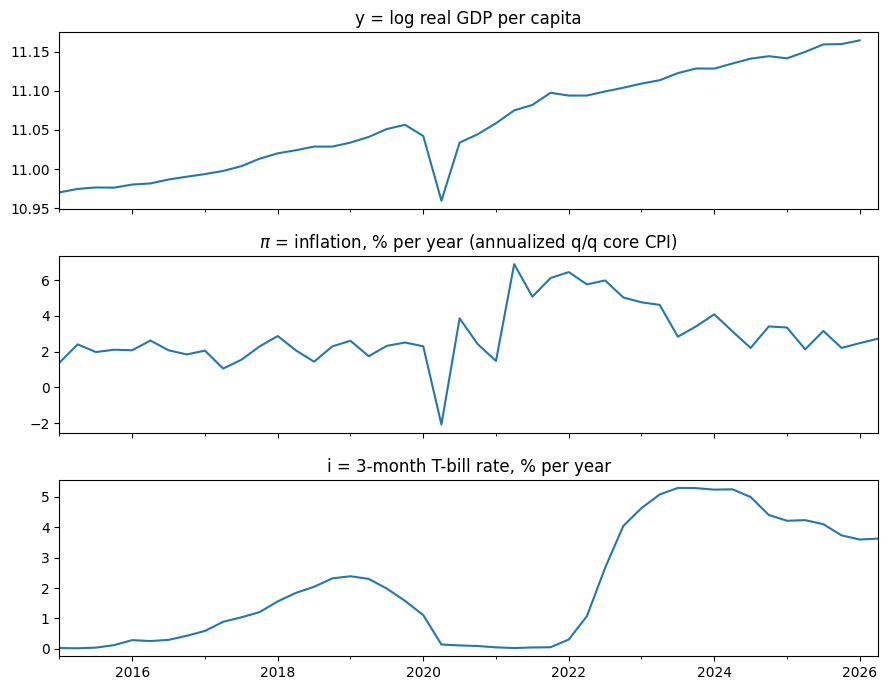

saved ../data/macro_y_pi_i_2015_2026Q2.csv (46, 3)
2015-01-01 -> 2026-04-01


In [9]:
# --- Restrict to 2015Q1 .. 2026Q2, quick look & save ----------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
macro_sample["y"].plot(ax=axes[0], title="y = log real GDP per capita")
macro_sample["pi"].plot(ax=axes[1], title=r"$\pi$ = inflation, % per year (annualized q/q core CPI)")
macro_sample["i"].plot(ax=axes[2], title="i = 3-month T-bill rate, % per year")
axes[2].set_xlabel("")
fig.tight_layout()
plt.show()

macro_sample.to_csv("../data/macro_y_pi_i_2015_2026Q2.csv")
print("saved ../data/macro_y_pi_i_2015_2026Q2.csv", macro_sample.shape)
print(macro_sample.index.min().date(), "->", macro_sample.index.max().date())


# Monthly stock prices

In [10]:
# Load weekly stock prices and average within each calendar month.
data_weekly = pd.read_csv(
    "../data/weekly_stock_prices.csv",
    parse_dates=["date_weekly"],
    index_col="date_weekly",
)

# Monthly average of the weekly prices; "MS" labels each month at its start (2015-01-01, ...).
data_monthly = data_weekly.resample("MS").mean().loc["2015-01-01":"2026-04-01"]

print(data_monthly.shape)
data_monthly.tail()

data_monthly.to_csv("../data/monthly_stock_prices.csv")


(136, 7)


# PCA of stock prices

In [11]:
from sklearn.decomposition import PCA

# Panel of monthly *log* prices for the 7 stocks (built above as `data_monthly`).
prices = np.log(data_monthly)

# Standardize each stock to mean 0, unit variance, so the PCA is on the correlation
# matrix -- otherwise the high-priced / high-variance names would dominate the factors.
Z = (prices - prices.mean()) / prices.std(ddof=0)

# Estimate the principal components (fit all, then keep the first five factors).
K = 5
pca = PCA()
scores = pca.fit_transform(Z.values)                       # T x 7 factor scores
factors = pd.DataFrame(scores[:, :K], index=prices.index,
                       columns=[f"PC{k}" for k in range(1, K + 1)])

# Principal components are sign-indeterminate; orient PC1 to move *with* the stocks.
if np.corrcoef(factors["PC1"], Z.mean(axis=1))[0, 1] < 0:
    factors["PC1"] *= -1
if np.corrcoef(factors["PC2"], Z["TSLA"])[0, 1] < 0:       # stable, reproducible sign for PC2
    factors["PC2"] *= -1

factors.head()

,PC1,PC2,PC3,PC4,PC5
date_weekly,,,,,
2015-01-01,-4.603866,0.633006,-0.707642,0.088720,-0.308925
2015-02-01,-4.409200,0.620825,-0.539699,0.054280,-0.235320
2015-03-01,-4.411971,0.513623,-0.593647,0.065161,-0.210391
2015-04-01,-4.362054,0.544835,-0.535803,0.011969,-0.241875
2015-05-01,-4.231842,0.646688,-0.418582,-0.034060,-0.260476


    explained cumulative
PC1    93.5 %     93.5 %
PC2     3.6 %     97.0 %
PC3     1.5 %     98.6 %
PC4     0.7 %     99.3 %
PC5     0.4 %     99.7 %

First 5 factors together explain 99.7% of the variance of the 7 log stock prices


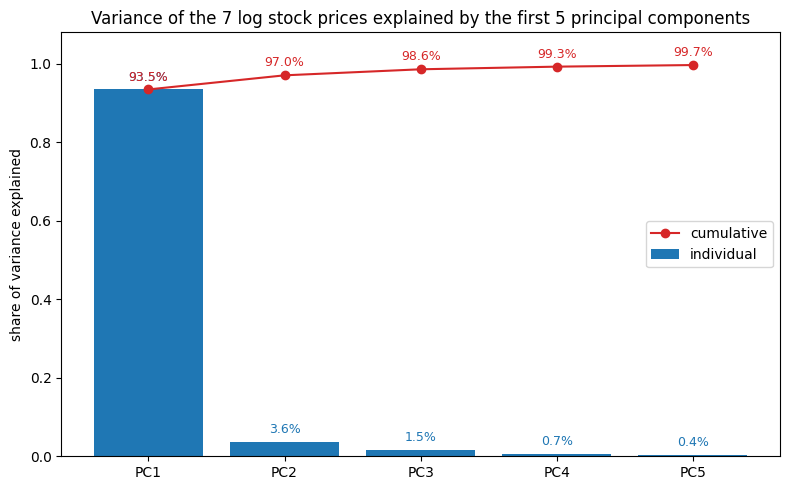

saved ../graph\pca_variance_explained.png


In [12]:
# --- How much variance do the first five factors explain? ----------------
import os

evr = pca.explained_variance_ratio_
top = pd.DataFrame(
    {"explained": evr[:K], "cumulative": np.cumsum(evr)[:K]},
    index=[f"PC{k}" for k in range(1, K + 1)],
)
print((top * 100).round(1).astype(str) + " %")
print(f"\nFirst {K} factors together explain {top['cumulative'].iloc[-1]:.1%} "
      f"of the variance of the 7 log stock prices")

# Scree plot: per-factor bars + cumulative line.
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(top.index, top["explained"], color="C0", label="individual")
ax.plot(top.index, top["cumulative"], color="C3", marker="o", label="cumulative")
for x, (e, c) in enumerate(zip(top["explained"], top["cumulative"])):
    ax.text(x, e + 0.015, f"{e:.1%}", ha="center", va="bottom", fontsize=9, color="C0")
    ax.text(x, c + 0.015, f"{c:.1%}", ha="center", va="bottom", fontsize=9, color="C3")
ax.set_ylim(0, 1.08)
ax.set_ylabel("share of variance explained")
ax.set_title("Variance of the 7 log stock prices explained by the first 5 principal components")
ax.legend(loc="center right")
plt.tight_layout()

# Save to the graph sub-directory.
graph_dir = "../graph"
os.makedirs(graph_dir, exist_ok=True)
out_path = os.path.join(graph_dir, "pca_variance_explained.png")
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved", out_path)

,PC1,y,pi,i
quarter,,,,
2015-01-01,-4.475012,10.970282,1.392663,0.026667
2015-04-01,-4.265935,10.974660,2.412452,0.020000
2015-07-01,-4.023953,10.976543,1.981025,0.040000
2015-10-01,-3.650274,10.976269,2.112163,0.123333
2016-01-01,-3.816788,10.980263,2.081514,0.286667
2016-04-01,-3.558130,10.981676,2.625879,0.256667
2016-07-01,-3.268109,10.986715,2.080846,0.296667
2016-10-01,-3.142927,10.990297,1.847306,0.430000
2017-01-01,-2.787647,10.993631,2.060563,0.590000


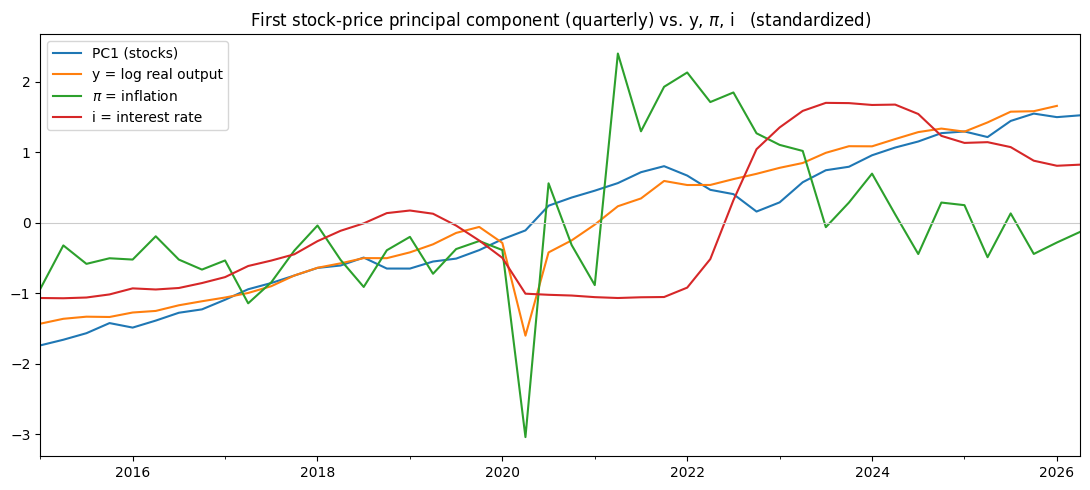

In [13]:
# --- First principal component at quarterly frequency, with y, pi, i -------

# Aggregate the monthly first PC to quarters (average within the quarter).
pc1_q = factors["PC1"].resample("QS").mean().rename("PC1")

# Line it up with the quarterly macro state computed earlier in this notebook.
combined = pd.concat([pc1_q, macro_sample[["y", "pi", "i"]]], axis=1)
combined.index.name = "quarter"
display(combined)

# Plot: standardize every series (z-score) so the PC and the macro variables,
# which live on very different scales, are visually comparable.
comp_z = (combined - combined.mean()) / combined.std()
ax = comp_z.plot(figsize=(11, 5))
ax.set_title("First stock-price principal component (quarterly) vs. y, $\\pi$, i   (standardized)")
ax.axhline(0, color="0.8", lw=0.8)
ax.set_xlabel("")
ax.legend(["PC1 (stocks)", "y = log real output", r"$\pi$ = inflation", "i = interest rate"])
plt.tight_layout()
plt.show()

# One-factor residual vs. firm fundamentals

Fit a **one-factor** PCA to the standardized log stock prices and take the
**residual** = standardized log price − one-factor fit. The residual is each firm's
*idiosyncratic* price component — the part not explained by the common (market/tech)
factor. A positive residual means the stock trades richer than the common factor alone
would imply.

We then correlate each firm's residual with its own 8 quarterly financial measures.

**Alignment.** Financial measures are dated at fiscal-period *ends*, and fiscal
calendars differ across firms (e.g. Nvidia's quarters end Jan/Apr/Jul/Oct), so each
measure observation is matched to the residual of the calendar month it falls in.

**Normalization (when appropriate).** The residual lives in log-price space, so the
strictly-positive measures (revenue, cost of revenue, gross profit, R&D, total assets,
equity) are **log-transformed** to match; operating income and net income are left in
levels because they are negative for some firms/years, where a log is undefined.

In [14]:
# --- One-factor model and its residual (idiosyncratic log price) ----------
# Z (standardized log prices) was built above.
pca1 = PCA(n_components=1)
common = pca1.fit_transform(Z.values)                 # T x 1 common factor score
fitted = pca1.inverse_transform(common)               # T x 7 one-factor fit
residual = pd.DataFrame(Z.values - fitted, index=Z.index, columns=Z.columns)

print(f"one factor explains {pca1.explained_variance_ratio_[0]:.1%} of the variance; "
      f"residual is the remaining {1 - pca1.explained_variance_ratio_[0]:.1%}")
residual.tail()

one factor explains 93.5% of the variance; residual is the remaining 6.5%


,AAPL,MSFT,AMZN,NVDA,GOOGL,TSLA,META
date_weekly,,,,,,,
2025-12-01,-0.121426,-0.254931,-0.286049,0.045370,0.490261,-0.118702,0.245981
2026-01-01,-0.197059,-0.308859,-0.223415,0.068388,0.569858,-0.159207,0.250926
2026-02-01,-0.090084,-0.422626,-0.349629,0.129745,0.575068,-0.140328,0.299507
2026-03-01,-0.094745,-0.396094,-0.291530,0.165562,0.539238,-0.136721,0.212911
2026-04-01,-0.124102,-0.451553,-0.164832,0.133139,0.600474,-0.242865,0.249329


In [15]:
# --- Correlate each firm's residual with its 8 (normalized) measures ------
panel = pd.read_csv("../data/firm_financials_panel/firm_financials_long.csv",
                    parse_dates=["date"])
panel["month"] = panel["date"].dt.to_period("M")

# Normalize when appropriate: log the strictly-positive measures, level otherwise.
POS_MEASURES = {"revenue", "cost_of_revenue", "gross_profit",
                "rd_expense", "total_assets", "stockholders_equity"}
panel["mval"] = panel["value"]
logmask = panel["measure"].isin(POS_MEASURES) & (panel["value"] > 0)
panel.loc[logmask, "mval"] = np.log(panel.loc[logmask, "value"])

# Residual to long form, keyed by (ticker, calendar month).
resid_long = (
    residual.rename_axis("date").reset_index()
    .melt(id_vars="date", var_name="ticker", value_name="resid")
)
resid_long["month"] = resid_long["date"].dt.to_period("M")

merged = panel.merge(resid_long[["ticker", "month", "resid"]], on=["ticker", "month"])

MIN_OBS = 8
corr = {}
for (ticker, measure), g in merged.groupby(["ticker", "measure"]):
    if g["mval"].notna().sum() >= MIN_OBS and g["mval"].std() > 0:
        corr[(ticker, measure)] = g["mval"].corr(g["resid"])

ROWS = ["AAPL", "MSFT", "AMZN", "NVDA", "GOOGL", "TSLA", "META"]
COLS = ["revenue", "cost_of_revenue", "gross_profit", "operating_income",
        "rd_expense", "net_income", "total_assets", "stockholders_equity"]
corr_mat = pd.Series(corr).unstack().reindex(index=ROWS, columns=COLS)
corr_mat.round(2)

,revenue,cost_of_revenue,gross_profit,operating_income,rd_expense,net_income,total_assets,stockholders_equity
AAPL,0.22,0.21,0.24,0.21,0.11,0.19,-0.34,-0.41
MSFT,0.23,0.18,0.25,0.10,0.28,0.10,0.12,0.15
AMZN,0.07,0.08,0.06,-0.17,NaN,-0.14,0.04,-0.00
NVDA,0.24,0.22,0.25,0.28,0.10,0.28,0.06,0.11
GOOGL,-0.06,-0.11,-0.02,0.09,-0.05,0.06,-0.13,-0.11
TSLA,0.04,0.01,0.15,0.48,0.04,0.39,-0.04,0.10
META,-0.09,-0.18,-0.07,0.27,-0.17,0.21,-0.06,-0.04


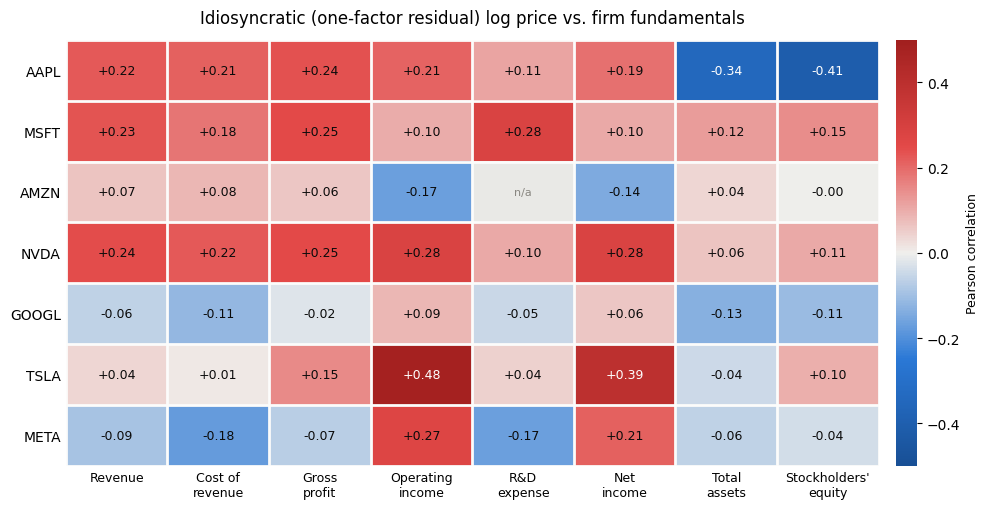

saved ../graph/residual_vs_measures_corr.png


In [16]:
# --- Heatmap: residual vs. measures (companies x measures) ----------------
from matplotlib.colors import LinearSegmentedColormap

# Diverging blue<->red with a gray midpoint at 0 (correlation is a polarity scale).
cmap = LinearSegmentedColormap.from_list(
    "blue_gray_red", ["#184f95", "#2a78d6", "#f0efec", "#e34948", "#a11f1e"]
)
cmap.set_bad("#e9e9e6")  # NaN cells (e.g. Amazon files no R&D tag)

C = corr_mat.values.astype(float)
vmax = max(0.3, np.ceil(np.nanmax(np.abs(C)) * 10) / 10)  # symmetric limits, 0 = gray

col_labels = ["Revenue", "Cost of\nrevenue", "Gross\nprofit", "Operating\nincome",
              "R&D\nexpense", "Net\nincome", "Total\nassets", "Stockholders'\nequity"]

fig, ax = plt.subplots(figsize=(10, 5.2))
im = ax.imshow(C, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")

ax.set_xticks(range(len(COLS)), labels=col_labels, fontsize=9)
ax.set_yticks(range(len(ROWS)), labels=ROWS, fontsize=10)
ax.tick_params(length=0)

# Annotate every cell so identity never rests on color alone.
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        v = C[i, j]
        if np.isnan(v):
            ax.text(j, i, "n/a", ha="center", va="center", color="#898781", fontsize=8)
        else:
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(v) > 0.60 * vmax else "#0b0b0b")

# 2px surface gap between cells.
ax.set_xticks(np.arange(-0.5, len(COLS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(ROWS), 1), minor=True)
ax.grid(which="minor", color="#fcfcfb", linewidth=2)
ax.tick_params(which="minor", length=0)
for s in ax.spines.values():
    s.set_visible(False)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Pearson correlation", fontsize=9)
cbar.outline.set_visible(False)


#fig.text(0.5, -0.02,
#         "Positive-only measures log-normalized; operating & net income in levels. "
#         "Correlations over aligned quarters.",
#         ha="center", fontsize=8, color="#52514e")


ax.set_title("Idiosyncratic (one-factor residual) log price vs. firm fundamentals",
             fontsize=12, pad=12)
plt.tight_layout()

os.makedirs("../graph", exist_ok=True)
out_path = "../graph/residual_vs_measures_corr.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved", out_path)